<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h1>Metaparameters</h1>
<p>Parameters (mainly weights and bias) are the params that the model learns during training.<br>Metaparameters are the ones not learned, but set by the developer. Examples include model architecture, number of hidden layers, number of units per layer, cross validation sizes, mini-batch size, activation functions, optimization functions, learning rate, dropout, loss function, data normalization, weight normalization, weight initialization, ... etc.</p>

<p>It is practically impossible to search through th entire metaparameter space, so it is impossible to know whether we are using the best settings.</p>

<h2>The wine quality dataset</h2>
</div>

In [93]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

In [94]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

data = pd.read_csv(url, sep=';')
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [95]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [96]:
for key in data.keys():
    print(f'{key} has {np.shape(np.unique(data[key]))[0]} unique values')

fixed acidity has 96 unique values
volatile acidity has 143 unique values
citric acid has 80 unique values
residual sugar has 91 unique values
chlorides has 153 unique values
free sulfur dioxide has 60 unique values
total sulfur dioxide has 144 unique values
density has 436 unique values
pH has 89 unique values
sulphates has 96 unique values
alcohol has 65 unique values
quality has 6 unique values


/tmp/ipykernel_801/2827752846.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


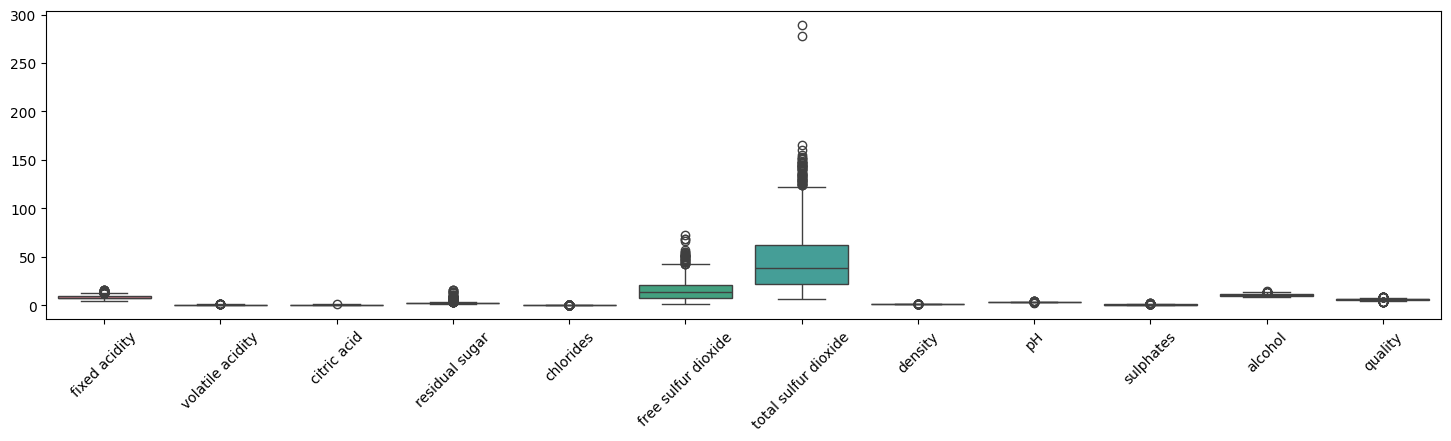

In [97]:
fig, ax = plt.subplots(1, figsize=(18, 4))
ax = sns.boxplot(data=data)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<p>Outliers can detriment the model quality, so we remove them.<br>The different scale of the data columns can also become a problem, so we z-score the columns.</p>
</div>

/tmp/ipykernel_801/150456138.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


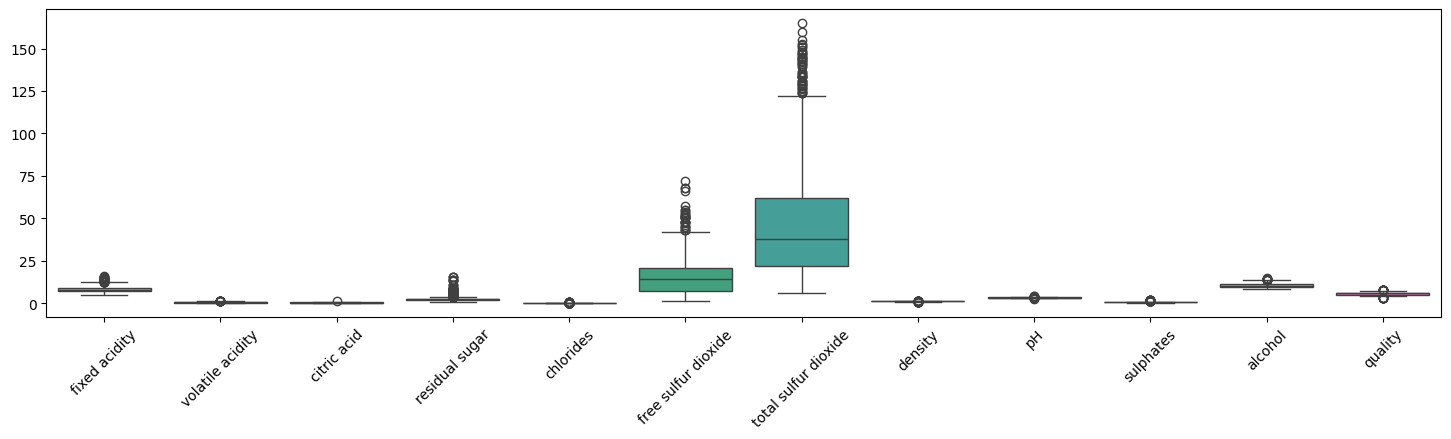

In [98]:
# outlier removal
data = data[data['total sulfur dioxide'] < 200]
fig, ax = plt.subplots(1, figsize=(18, 4))
ax = sns.boxplot(data=data)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()

In [99]:
# z-score
columnsToZscore = data.keys()
columnsToZscore = columnsToZscore.drop('quality')

for column in columnsToZscore:
    mean = np.mean(data[column])
    std = np.std(data[column], ddof=1)
    data[column] = (data[column] - mean) / std
# alternatively: data[columnsToZscore].apply(stats.zscore)

/tmp/ipykernel_801/2827752846.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


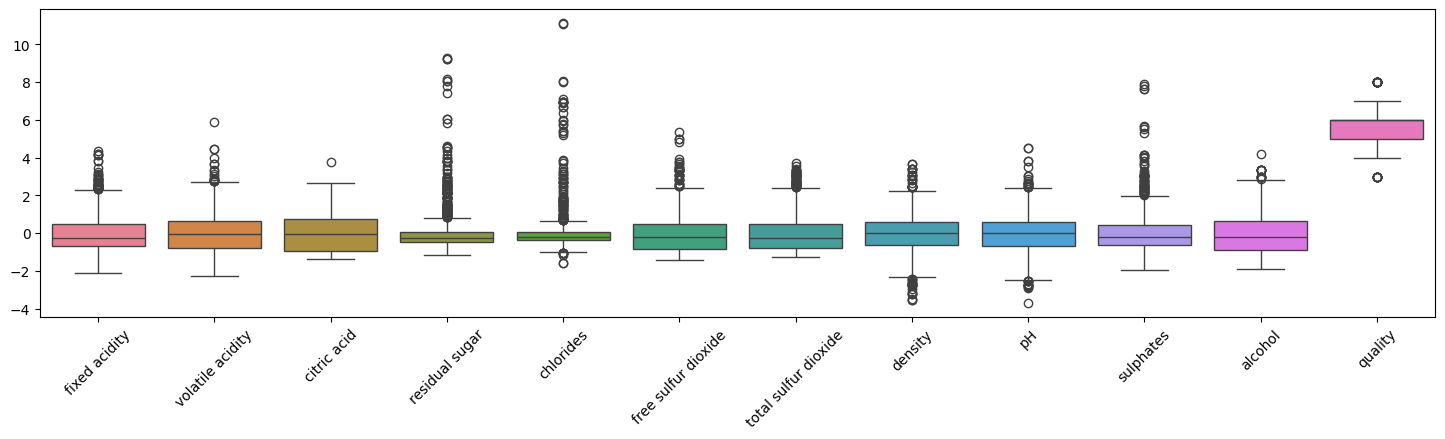

In [100]:
fig, ax = plt.subplots(1, figsize=(18, 4))
ax = sns.boxplot(data=data)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()

In [101]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1597.000000
mean,1.779694e-17,1.156801e-16,1.779694e-17,-7.563699e-17,-1.512740e-16,-1.779694e-17,-7.118775e-17,-8.357442e-14,3.025479e-16,8.008622e-17,-5.872989e-16,5.634314
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.806630
min,-2.135419e+00,-2.280048e+00,-1.391387e+00,-1.168783e+00,-1.604073e+00,-1.422392e+00,-1.262186e+00,-3.545821e+00,-3.708218e+00,-1.936711e+00,-1.898626e+00,3.000000
25%,-7.003882e-01,-7.715838e-01,-9.283861e-01,-4.524372e-01,-3.720247e-01,-8.476045e-01,-7.594598e-01,-6.109478e-01,-6.585382e-01,-6.390204e-01,-8.650444e-01,5.000000
50%,-2.411785e-01,-4.528645e-02,-5.382836e-02,-2.375335e-01,-1.808448e-01,-1.770192e-01,-2.567340e-01,-6.214425e-04,-9.670044e-03,-2.261189e-01,-2.073106e-01,6.000000
75%,5.050372e-01,6.251419e-01,7.692848e-01,4.900487e-02,5.281955e-02,4.935662e-01,4.973546e-01,5.778618e-01,5.743113e-01,4.227263e-01,6.383472e-01,6.000000
max,4.350918e+00,5.876831e+00,3.753070e+00,9.289866e+00,1.112001e+01,5.379259e+00,3.733652e+00,3.682565e+00,4.532407e+00,7.913939e+00,4.208902e+00,8.000000


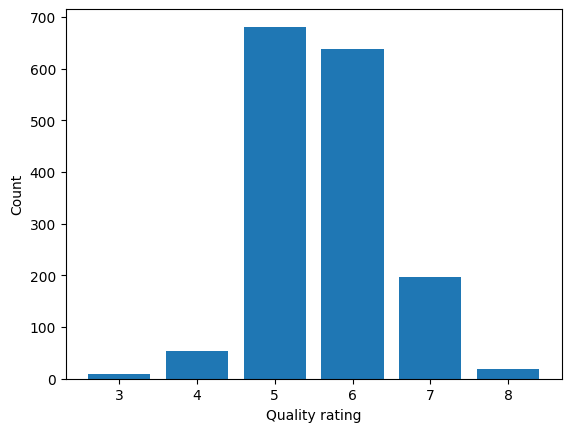

In [102]:
qualityCounts = data['quality'].value_counts()
keys = list(qualityCounts.keys())
values = list(qualityCounts)

plt.bar(keys, values)
plt.xlabel('Quality rating')
plt.ylabel('Count')
plt.show()

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<p>Usually it is desirable for the dependent variable (quality) to have roughly the same number of data points in each value. We can do it by having a new column called boolQuality.</p>
</div>

In [103]:
data['boolQuality'] = data['quality'] > 5
print(f'Number of good quality wines: {np.shape(data[data['boolQuality'] == True])[0]}')
print(f'Number of poor quality wines: {np.shape(data[data['boolQuality'] == False])[0]}')

Number of good quality wines: 853
Number of poor quality wines: 744


In [104]:
dataTensor = torch.tensor(data[columnsToZscore].values).float()
labels = torch.tensor(data['boolQuality'].values).float()

print(dataTensor.shape)
print(labels.shape)

labels = labels[:,None]
print(labels.shape)

torch.Size([1597, 11])
torch.Size([1597])
torch.Size([1597, 1])


In [105]:
trainData, testData, trainLabels, testLabels = train_test_split(dataTensor, labels, test_size=0.2)

trainData = TensorDataset(trainData, trainLabels)
testData = TensorDataset(testData, testLabels)

batchSize = 64
trainLoader = DataLoader(trainData, batch_size=batchSize, shuffle=True)
testLoader = DataLoader(testData, batch_size=testData.tensors[0].shape[0])